# 15. Classification — Univariate LSTM

**Input**: A single feature — raw `Close` price (scaled), one value per timestep.  
**Scratch**: Full 4-gate LSTM with BPTT + Adam, pure NumPy.  
**PyTorch**: `nn.LSTM(input_size=1) → nn.Linear → Sigmoid`.

### Why Univariate?
A univariate LSTM tests whether **temporal price patterns alone** carry predictive signal, without any engineered features. It is the simplest possible sequence model for this task.

### Theory

With a single input $x_t \in \mathbb{R}$ at each timestep, the LSTM gates become:

$$f_t = \sigma(w_f^x x_t + w_f^h h_{t-1} + b_f) \qquad \text{forget gate}$$
$$i_t = \sigma(w_i^x x_t + w_i^h h_{t-1} + b_i) \qquad \text{input gate}$$
$$\tilde{c}_t = \tanh(w_c^x x_t + w_c^h h_{t-1} + b_c) \qquad \text{cell candidate}$$
$$o_t = \sigma(w_o^x x_t + w_o^h h_{t-1} + b_o) \qquad \text{output gate}$$

**State updates** (identical to multivariate LSTM):
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

After processing all $T=24$ timesteps, $h_T$ passes through a Linear + Sigmoid head:
$$\hat{y} = \sigma(W_y h_T + b_y)$$

The weight matrices $W_x \in \mathbb{R}^{4H \times 1}$, $W_h \in \mathbb{R}^{4H \times H}$ are stacked for efficiency.

### Data pipeline
```
btc_1h_data_2018_to_2025.csv  →  Close column
         ↓  align by 'open time' with train/test CSVs (which carry target_class)
  StandardScaler (fit on train only)
         ↓  make_windows(window=24)  →  shape (N, 24, 1)
  LSTMScratch / LSTMModel
```

In [1]:
!pip install torch --quiet

In [2]:
import os, json, pickle, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RAW_CSV     = os.path.join(BASE_DIR, 'preprocessing-May', 'btc_1h_data_2018_to_2025.csv')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
PLOTS_DIR   = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV = os.path.join(RESULTS_DIR, 'classification_results.csv')

for d in [MODELS_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Shared utilities ───────────────────────────────────────────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity / (precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"  Recall           : {sensitivity:.4f}")
    print(f"{'='*55}")
    return {
        'model':       model_name,
        'accuracy':    round(accuracy,    4),
        'precision':   round(precision,   4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'tnr':         round(specificity, 4),
        'f1':          round(f1,          4),
        'roc_auc':     round(auc, 4) if not np.isnan(auc) else None,
        'tp':          int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'recall':      round(sensitivity, 4),
    }

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"  ✔ Results saved → {RESULTS_CSV}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✔ Saved: {save_path}")

print("Imports ready. PyTorch:", torch.__version__)
print("BASE_DIR:", BASE_DIR)

Imports ready. PyTorch: 2.10.0
BASE_DIR: /Users/mihiniboteju/cryptoflow


## 1. Data Preparation

Load raw `Close` prices from the BTC CSV, align timestamps with train/test split CSVs (which carry `target_class`), then scale and build sliding windows of length 24.

In [3]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW     = 48    # lookback timesteps (1 full day of hourly bars)
HIDDEN     = 64    # LSTM hidden units
N_LAYERS   = 1
EPOCHS     = 50
PATIENCE   = 10
BATCH_SIZE = 64
LR         = 0.001
VAL_FRAC   = 0.10  # last 10% of training windows used for validation

# ── Load raw BTC hourly data — extract Close price + timestamp ─────────────────
raw_df = pd.read_csv(RAW_CSV)
raw_df.columns = raw_df.columns.str.strip()
raw_df['open_time'] = pd.to_datetime(raw_df['Open time'].str.strip())
raw_df = raw_df[['open_time', 'Close']].rename(columns={'Close': 'close'}).sort_values('open_time')
print(f"Raw data: {len(raw_df):,} rows  |  {raw_df['open_time'].min()} → {raw_df['open_time'].max()}")

# ── Load train / test CSVs (for timestamps + target_class) ────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))

train_df['open_time'] = pd.to_datetime(train_df['open time'])
test_df['open_time']  = pd.to_datetime(test_df['open time'])

# ── Merge Close price into train/test via timestamp ───────────────────────────
train_merged = train_df[['open_time', 'target_class']].merge(raw_df, on='open_time', how='inner')
test_merged  = test_df[['open_time', 'target_class']].merge(raw_df, on='open_time', how='inner')

print(f"Train after merge: {len(train_merged):,} rows")
print(f"Test  after merge: {len(test_merged):,} rows")

# ── Scale Close price (fit only on train) ─────────────────────────────────────
scaler = StandardScaler()
X_sc_train = scaler.fit_transform(train_merged[['close']].values).astype(np.float32)
X_sc_test  = scaler.transform(test_merged[['close']].values).astype(np.float32)
y_train    = train_merged['target_class'].values.astype(np.int64)
y_test     = test_merged['target_class'].values.astype(np.int64)

scaler_path = os.path.join(MODELS_DIR, 'scaler_lstm_univariate.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✔ Scaler saved → {scaler_path}")

# ── Build sliding windows (N, 24, 1) ──────────────────────────────────────────
def make_windows(X, y, window):
    """X_win[i] = X[i : i+window],  y_win[i] = y[i+window]"""
    n = len(X) - window
    X_win = np.stack([X[i:i+window] for i in range(n)], axis=0)  # (N, W, 1)
    y_win = y[window:]
    return X_win, y_win

X_win_train, y_win_train = make_windows(X_sc_train, y_train, WINDOW)
X_win_test,  y_win_test  = make_windows(X_sc_test,  y_test,  WINDOW)

# ── Temporal validation split ──────────────────────────────────────────────────
n_val = int(len(X_win_train) * VAL_FRAC)
n_tr  = len(X_win_train) - n_val

X_tr, X_val = X_win_train[:n_tr], X_win_train[n_tr:]
y_tr, y_val = y_win_train[:n_tr], y_win_train[n_tr:]

print(f"\nWindowed shapes  (N, timesteps, features):")
print(f"  X_tr   : {X_tr.shape}   y_tr   : {y_tr.shape}")
print(f"  X_val  : {X_val.shape}   y_val  : {y_val.shape}")
print(f"  X_test : {X_win_test.shape}  y_test : {y_win_test.shape}")

Raw data: 70,847 rows  |  2018-01-01 00:00:00 → 2026-02-04 21:00:00
Train after merge: 60,140 rows
Test  after merge: 10,635 rows
  ✔ Scaler saved → /Users/mihiniboteju/cryptoflow/models/scaler_lstm_univariate.pkl

Windowed shapes  (N, timesteps, features):
  X_tr   : (54105, 24, 1)   y_tr   : (54105,)
  X_val  : (6011, 24, 1)   y_val  : (6011,)
  X_test : (10611, 24, 1)  y_test : (10611,)


## Part 1 — Scratch LSTM (NumPy + Adam)

Full 4-gate LSTM implemented from scratch with BPTT and Adam optimiser.  
Weight matrices are stacked as a single $(4H \times (H+1))$ matrix and sliced per gate during the forward pass.  
Training uses mini-batch SGD with early stopping on validation loss.

In [4]:
class LSTMScratch:
    """
    Single-layer LSTM, pure NumPy, input_dim=1 (univariate).
    Stacked weight matrix: Wx (4H×D), Wh (4H×H), b (4H).
    Adam optimiser, BCE loss, early stopping on val loss.
    """
    def __init__(self, input_dim=1, hidden_dim=64, lr=0.001,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        self.D   = input_dim
        self.H   = hidden_dim
        self.lr  = lr
        self.b1  = beta1
        self.b2  = beta2
        self.eps = eps

        scale_W = np.sqrt(2.0 / (input_dim + hidden_dim))
        scale_U = np.sqrt(2.0 / (hidden_dim + hidden_dim))

        self.Wx = np.random.randn(4*hidden_dim, input_dim)  * scale_W
        self.Wh = np.random.randn(4*hidden_dim, hidden_dim) * scale_U
        self.b  = np.zeros(4 * hidden_dim)
        self.Wy = np.random.randn(hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.by = np.array([0.0])

        params = ['Wx', 'Wh', 'b', 'Wy', 'by']
        self._m = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in params}
        self._t = 0

    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    def _forward_sequence(self, x_seq):
        """x_seq: (T, 1). Returns hs, cs, gates for BPTT."""
        T = len(x_seq); H = self.H
        h = np.zeros(H); c = np.zeros(H)
        hs, cs, gates = [h.copy()], [c.copy()], []
        for t in range(T):
            z = self.Wx @ x_seq[t] + self.Wh @ h + self.b
            f = self._sigmoid(z[0*H:1*H])
            i = self._sigmoid(z[1*H:2*H])
            g = np.tanh(     z[2*H:3*H])
            o = self._sigmoid(z[3*H:4*H])
            c = f * cs[-1] + i * g
            h = o * np.tanh(c)
            hs.append(h.copy()); cs.append(c.copy())
            gates.append((f, i, g, o, z, x_seq[t]))
        return hs, cs, gates

    def _predict_one(self, x_seq):
        hs, cs, _ = self._forward_sequence(x_seq)
        logit = self.Wy @ hs[-1] + self.by
        return float(self._sigmoid(logit)), hs[-1]

    def _backward_one(self, x_seq, y, p):
        hs, cs, gates = self._forward_sequence(x_seq)
        T = len(x_seq); H = self.H
        dy   = p - y
        dWy  = dy * hs[-1]
        dby  = np.array([dy])
        dh_next = dy * self.Wy
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        db  = np.zeros_like(self.b)
        dc_next = np.zeros(H)
        for t in reversed(range(T)):
            f, i, g, o, z, x_t = gates[t]
            c_t = cs[t+1]
            tanh_c = np.tanh(c_t)
            dh = dh_next
            dc = dh * o * (1 - tanh_c**2) + dc_next
            dz = np.concatenate([
                dc * cs[t] * f * (1-f),
                dc * g     * i * (1-i),
                dc * i     * (1 - g**2),
                dh * tanh_c * o * (1-o),
            ])
            dWx += np.outer(dz, x_t)
            dWh += np.outer(dz, hs[t])
            db  += dz
            dc_next = dc * f
            dh_next = self.Wh.T @ dz
        return {'Wx': dWx, 'Wh': dWh, 'b': db, 'Wy': dWy, 'by': dby}

    def _adam_step(self, grads):
        self._t += 1
        for pname, grad in grads.items():
            self._m[pname] = self.b1 * self._m[pname] + (1-self.b1) * grad
            self._v[pname] = self.b2 * self._v[pname] + (1-self.b2) * grad**2
            m_hat = self._m[pname] / (1 - self.b1**self._t)
            v_hat = self._v[pname] / (1 - self.b2**self._t)
            setattr(self, pname,
                    getattr(self, pname) - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))

    @staticmethod
    def _bce(y_true, y_prob):
        y_prob = np.clip(y_prob, 1e-12, 1-1e-12)
        return -np.mean(y_true * np.log(y_prob) + (1-y_true) * np.log(1-y_prob))

    def fit(self, X_tr, y_tr, X_val, y_val,
            epochs=50, batch_size=64, patience=10):
        """Mini-batch SGD with early stopping. Subsamples every 4th train seq for speed."""
        # subsample for speed — still temporal order preserved within batches
        X_sub = X_tr[::4]; y_sub = y_tr[::4]
        n = len(X_sub)
        best_val = np.inf; wait = 0; best_params = None
        train_losses, val_losses = [], []

        for epoch in range(1, epochs+1):
            t0 = time.time()
            idx = np.random.permutation(n)
            epoch_loss = 0.0
            n_batches = 0

            for start in range(0, n, batch_size):
                batch_idx = idx[start:start+batch_size]
                acc_grads = {p: np.zeros_like(getattr(self, p))
                             for p in ['Wx','Wh','b','Wy','by']}
                probs = []
                for j in batch_idx:
                    p, _ = self._predict_one(X_sub[j])
                    probs.append(p)
                    g = self._backward_one(X_sub[j], y_sub[j], p)
                    for pname in acc_grads:
                        acc_grads[pname] += g[pname]
                bs = len(batch_idx)
                for pname in acc_grads:
                    acc_grads[pname] /= bs
                self._adam_step(acc_grads)
                epoch_loss += self._bce(y_sub[batch_idx], np.array(probs))
                n_batches  += 1

            epoch_loss /= max(1, n_batches)
            train_losses.append(epoch_loss)

            val_probs = np.array([self._predict_one(X_val[j])[0] for j in range(len(X_val))])
            val_loss  = self._bce(y_val, val_probs)
            val_losses.append(val_loss)

            print(f"  Epoch {epoch:>3}/{epochs}  "
                  f"train={epoch_loss:.4f}  val={val_loss:.4f}  "
                  f"({time.time()-t0:.1f}s)")

            if val_loss < best_val:
                best_val = val_loss; wait = 0
                best_params = {p: getattr(self, p).copy()
                               for p in ['Wx','Wh','b','Wy','by']}
            else:
                wait += 1
                if wait >= patience:
                    print(f"  Early stopping at epoch {epoch} (best val={best_val:.4f})")
                    break

        if best_params:
            for p, v in best_params.items():
                setattr(self, p, v)
        return train_losses, val_losses

    def predict_proba(self, X):
        return np.array([self._predict_one(X[i])[0] for i in range(len(X))])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("LSTMScratch class defined.")

LSTMScratch class defined.


In [5]:
np.random.seed(42)
lstm_scratch = LSTMScratch(input_dim=1, hidden_dim=HIDDEN, lr=LR)

print("Training LSTM Univariate Scratch …")
scratch_train_losses, scratch_val_losses = lstm_scratch.fit(
    X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE
)
print("Done.")

Training LSTM Univariate Scratch …
  Epoch   1/50  train=0.6935  val=0.6955  (60.6s)
  Epoch   2/50  train=0.6932  val=0.6931  (50.5s)
  Epoch   3/50  train=0.6930  val=0.6948  (52.3s)
  Epoch   4/50  train=0.6930  val=0.6934  (53.2s)
  Epoch   5/50  train=0.6930  val=0.6932  (50.1s)
  Epoch   6/50  train=0.6930  val=0.6931  (52.5s)
  Epoch   7/50  train=0.6930  val=0.6937  (53.6s)
  Epoch   8/50  train=0.6930  val=0.6933  (51.6s)
  Epoch   9/50  train=0.6930  val=0.6931  (50.4s)
  Epoch  10/50  train=0.6928  val=0.6938  (56.8s)
  Epoch  11/50  train=0.6930  val=0.6931  (51.3s)
  Epoch  12/50  train=0.6929  val=0.6930  (50.3s)
  Epoch  13/50  train=0.6930  val=0.6932  (63.6s)
  Epoch  14/50  train=0.6929  val=0.6931  (64.9s)
  Epoch  15/50  train=0.6929  val=0.6931  (74.7s)
  Epoch  16/50  train=0.6929  val=0.6932  (70.0s)
  Epoch  17/50  train=0.6929  val=0.6931  (55.5s)
  Epoch  18/50  train=0.6929  val=0.6930  (52.5s)
  Epoch  19/50  train=0.6929  val=0.6930  (64.6s)
  Epoch  20/50 


  LSTM Univariate Scratch
  Confusion Matrix : TN=5104  FP=165  FN=5164  TP=178
  Accuracy         : 0.4978
  Precision        : 0.5190
  Sensitivity      : 0.0333
  Specificity(TNR) : 0.9687
  F1-Score         : 0.0626
  ROC-AUC          : 0.5050
  Recall           : 0.0333
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv


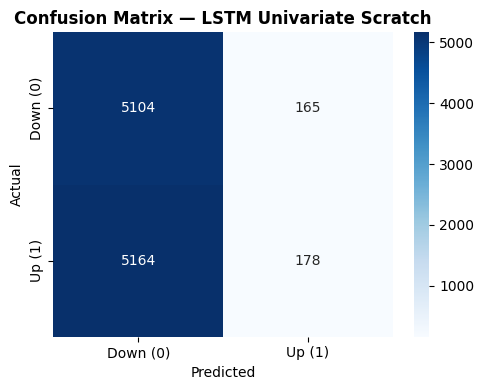

  ✔ Saved: /Users/mihiniboteju/cryptoflow/plots/confusion_lstm_univariate_scratch.png


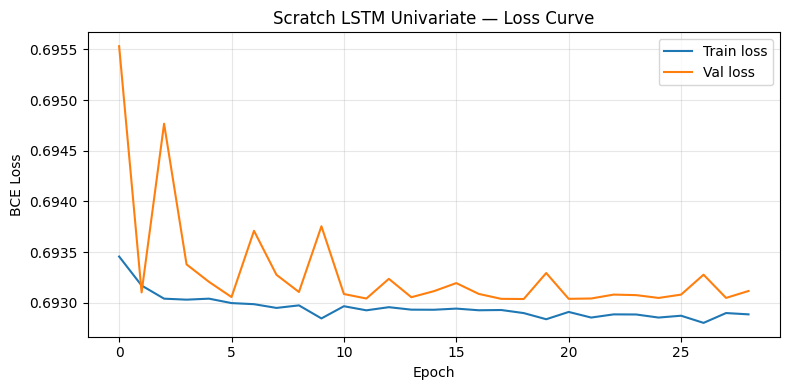

  ✔ Scratch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_univariate_scratch.pkl


In [6]:
# ── Evaluate ───────────────────────────────────────────────────────────────────
scratch_prob = lstm_scratch.predict_proba(X_win_test)
scratch_pred = lstm_scratch.predict(X_win_test)
scratch_metrics = compute_metrics('LSTM Univariate Scratch', y_win_test, scratch_pred, scratch_prob)
save_results(scratch_metrics)

plot_confusion_matrix(y_win_test, scratch_pred,
                      'LSTM Univariate Scratch',
                      os.path.join(PLOTS_DIR, 'confusion_lstm_univariate_scratch.png'))

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_train_losses, label='Train loss')
ax.plot(scratch_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Scratch LSTM Univariate — Loss Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'loss_lstm_univariate_scratch.png'), dpi=150)
plt.show()

# Save model
scratch_path = os.path.join(MODELS_DIR, 'lstm_univariate_scratch.pkl')
with open(scratch_path, 'wb') as f:
    pickle.dump(lstm_scratch, f)
print(f"  ✔ Scratch model saved → {scratch_path}")

## Part 2 — PyTorch LSTM

`nn.LSTM(input_size=1, hidden_size=64, num_layers=1, batch_first=True)`  
→ `Dropout(0.3)` → `Linear(64, 1)` → `Sigmoid`  

Adam optimiser with `weight_decay=1e-4`, gradient clipping `max_norm=1.0`, early stopping on val loss.

In [7]:
class LSTMModel(nn.Module):
    """Univariate LSTM: input_size=1 → hidden_size=64 → Linear → Sigmoid."""
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm    = nn.LSTM(input_dim, hidden_dim,
                               num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)           # (batch, seq, hidden)
        h_last = self.dropout(out[:, -1, :])  # last timestep
        return torch.sigmoid(self.linear(h_last)).squeeze(1)


def train_pytorch_lstm(model, X_tr, y_tr, X_val, y_val,
                       epochs, batch_size, patience, lr, device='cpu'):
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32, device=device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    loader  = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                         batch_size=batch_size, shuffle=True)

    best_val = np.inf; best_state = None; wait = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs+1):
        model.train()
        t0 = time.time(); epoch_loss = 0.0
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_tr)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        print(f"  Epoch {epoch:>3}/{epochs}  "
              f"train={epoch_loss:.4f}  val={val_loss:.4f}  "
              f"({time.time()-t0:.1f}s)")

        if val_loss < best_val:
            best_val = val_loss; wait = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch} (best val={best_val:.4f})")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print("LSTMModel + train function defined.")

Device: cpu
LSTMModel + train function defined.


In [8]:
pt_model = LSTMModel(input_dim=1, hidden_dim=HIDDEN, num_layers=N_LAYERS, dropout=0.3)

print("Training LSTM Univariate PyTorch …")
pt_model, pt_train_losses, pt_val_losses = train_pytorch_lstm(
    pt_model, X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE, lr=LR, device=DEVICE
)
print("Done.")

Training LSTM Univariate PyTorch …
  Epoch   1/50  train=0.6932  val=0.6937  (6.6s)
  Epoch   2/50  train=0.6931  val=0.6930  (6.6s)
  Epoch   3/50  train=0.6931  val=0.6930  (6.9s)
  Epoch   4/50  train=0.6931  val=0.6930  (8.5s)
  Epoch   5/50  train=0.6930  val=0.6930  (6.7s)
  Epoch   6/50  train=0.6930  val=0.6930  (8.2s)
  Epoch   7/50  train=0.6930  val=0.6930  (6.8s)
  Epoch   8/50  train=0.6930  val=0.6930  (6.8s)
  Epoch   9/50  train=0.6930  val=0.6930  (6.6s)
  Epoch  10/50  train=0.6930  val=0.6931  (7.8s)
  Epoch  11/50  train=0.6930  val=0.6932  (6.8s)
  Epoch  12/50  train=0.6930  val=0.6931  (6.7s)
  Epoch  13/50  train=0.6930  val=0.6930  (7.1s)
  Epoch  14/50  train=0.6930  val=0.6931  (7.5s)
  Epoch  15/50  train=0.6930  val=0.6933  (8.8s)
  Epoch  16/50  train=0.6930  val=0.6930  (7.7s)
  Epoch  17/50  train=0.6930  val=0.6930  (7.6s)
  Epoch  18/50  train=0.6930  val=0.6930  (8.0s)
  Epoch  19/50  train=0.6930  val=0.6930  (8.2s)
  Early stopping at epoch 19 (best


  LSTM Univariate PyTorch
  Confusion Matrix : TN=0  FP=5269  FN=0  TP=5342
  Accuracy         : 0.5034
  Precision        : 0.5034
  Sensitivity      : 1.0000
  Specificity(TNR) : 0.0000
  F1-Score         : 0.6697
  ROC-AUC          : 0.5039
  Recall           : 1.0000
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv


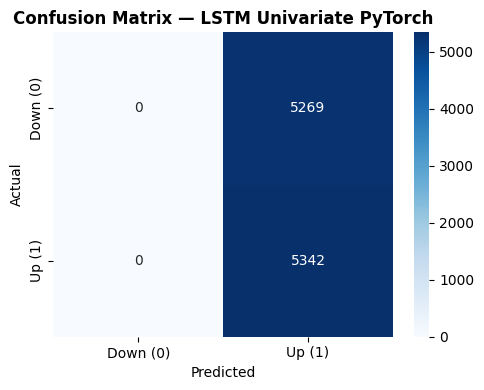

  ✔ Saved: /Users/mihiniboteju/cryptoflow/plots/confusion_lstm_univariate_pytorch.png


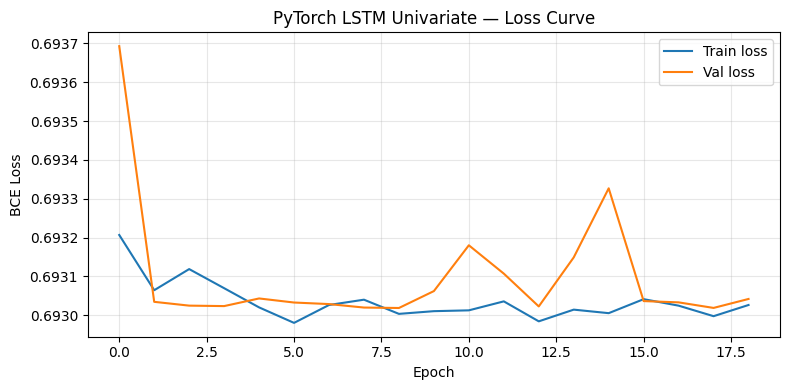

  ✔ PyTorch model saved → /Users/mihiniboteju/cryptoflow/models/lstm_univariate_pytorch.pth


In [9]:
# ── Evaluate ───────────────────────────────────────────────────────────────────
pt_model.eval()
with torch.no_grad():
    pt_prob = pt_model(
        torch.tensor(X_win_test, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy()

pt_pred = (pt_prob >= 0.5).astype(int)
pt_metrics = compute_metrics('LSTM Univariate PyTorch', y_win_test, pt_pred, pt_prob)
save_results(pt_metrics)

plot_confusion_matrix(y_win_test, pt_pred,
                      'LSTM Univariate PyTorch',
                      os.path.join(PLOTS_DIR, 'confusion_lstm_univariate_pytorch.png'))

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pt_train_losses, label='Train loss')
ax.plot(pt_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('PyTorch LSTM Univariate — Loss Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'loss_lstm_univariate_pytorch.png'), dpi=150)
plt.show()

# Save model
pt_path = os.path.join(MODELS_DIR, 'lstm_univariate_pytorch.pth')
torch.save(pt_model.state_dict(), pt_path)
print(f"  ✔ PyTorch model saved → {pt_path}")

## ROC Curve Comparison

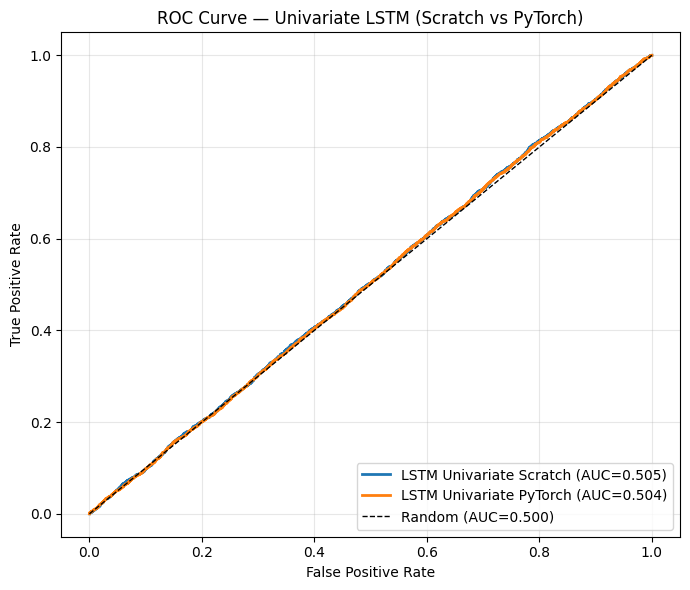

  ✔ ROC saved → /Users/mihiniboteju/cryptoflow/plots/roc_lstm_univariate.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for label, probs in [('LSTM Univariate Scratch', scratch_prob),
                     ('LSTM Univariate PyTorch', pt_prob)]:
    fpr, tpr, _ = roc_curve(y_win_test, probs)
    auc_val      = roc_auc_score(y_win_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Univariate LSTM (Scratch vs PyTorch)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(PLOTS_DIR, 'roc_lstm_univariate.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✔ ROC saved → {roc_path}")

## Results Summary

In [11]:
results_df = pd.read_csv(RESULTS_CSV)
univariate_rows = results_df[results_df['model'].str.contains('Univariate')]

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("=== Univariate LSTM Results ===")
print(univariate_rows.to_string(index=False))

print("\n=== Full Classification Results ===")
print(results_df.to_string(index=False))

=== Univariate LSTM Results ===
                  model  accuracy  precision  sensitivity  specificity    tnr     f1  roc_auc   tp   tn   fp   fn  recall
LSTM Univariate Scratch    0.4978     0.5190       0.0333       0.9687 0.9687 0.0626   0.5050  178 5104  165 5164  0.0333
LSTM Univariate PyTorch    0.5034     0.5034       1.0000       0.0000 0.0000 0.6697   0.5039 5342    0 5269    0  1.0000

=== Full Classification Results ===
                                  model  accuracy  precision  sensitivity  specificity    tnr     f1  roc_auc   tp   tn   fp   fn  recall
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.0000 0.6697   0.5000 5354    0 5281    0     NaN
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5137 0.5300   0.5388 2856 2713 2568 2498     NaN
          Logistic Regression (sklearn)    0.5247     0.5275       0.5347       0.5145 0.5145 0.5311   0.5386 2863 2717 2564 2491     NaN
             